## Final Project
## Name: [Yixiao Zhang]
## Link to your the github repo: [https://github.com/adelezhangyi/DATA-1030-Project.git]

In [1]:
from __future__ import print_function
from packaging.version import parse as Version
from platform import python_version

OK = '\x1b[42m[ OK ]\x1b[0m'
FAIL = "\x1b[41m[FAIL]\x1b[0m"

try:
    import importlib
except ImportError:
    print(FAIL, "Python version 3.12 is required,"
                " but %s is installed." % sys.version)

def import_version(pkg, min_ver, fail_msg=""):
    mod = None
    try:
        mod = importlib.import_module(pkg)
        if pkg in {'PIL'}:
            ver = mod.VERSION
        else:
            ver = mod.__version__
        if Version(ver) == Version(min_ver):
            print(OK, "%s version %s is installed."
                  % (lib, min_ver))
        else:
            print(FAIL, "%s version %s is required, but %s installed."
                  % (lib, min_ver, ver))    
    except ImportError:
        print(FAIL, '%s not installed. %s' % (pkg, fail_msg))
    return mod


# first check the python version
pyversion = Version(python_version())

if pyversion >= Version("3.12.5"):
    print(OK, "Python version is %s" % pyversion)
elif pyversion < Version("3.12.5"):
    print(FAIL, "Python version 3.12.5 is required,"
                " but %s is installed." % pyversion)
else:
    print(FAIL, "Unknown Python version: %s" % pyversion)

    
print()
requirements = {'numpy': "1.26.4", 'matplotlib': "3.9.2",'sklearn': "1.5.1", 
                'pandas': "2.2.2",'xgboost': "2.1.1", 'shap': "0.45.1", 
                'plotly': "5.23.0"}

# now the dependencies
for lib, required_version in list(requirements.items()):
    import_version(lib, required_version)

[ OK ] Python version is 3.12.5

[ OK ] numpy version 1.26.4 is installed.
[ OK ] matplotlib version 3.9.2 is installed.
[ OK ] sklearn version 1.5.1 is installed.
[ OK ] pandas version 2.2.2 is installed.
[ OK ] xgboost version 2.1.1 is installed.
[ OK ] shap version 0.45.1 is installed.
[ OK ] plotly version 5.23.0 is installed.


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('marketing_campaign_data.csv')
print("Number of datapoints:", len(df))
print(df.head())
df.shape[1]


Number of datapoints: 2240
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524      1957.0  Graduation         Single  58138.0        0         0   
1  2174         NaN  Graduation         Single  46344.0        1         1   
2  4141         NaN  Graduation       Together      NaN        0         0   
3  6182         NaN  Graduation       Together  26646.0        1         0   
4  5324         NaN         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       NaN  ...                  7             0   
1  08-03-2014       38       NaN  ...                  5             0   
2  21-08-2013       26     426.0  ...                  4             0   
3  10-02-2014       26      11.0  ...                  6             0   
4  19-01-2014       94     173.0  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  

29

## Exploratory Data Analysis (EDA)

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,1162.0,1968.864028,11.531349,1940.0,1960.00,1970.0,1977.00,1995.0
Income,1150.0,51604.226087,21625.580361,2447.0,35182.50,50840.0,67429.75,160803.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,1162.0,305.436317,341.467278,0.0,23.00,175.5,502.75,1493.0
MntFruits,1162.0,26.387263,38.992609,0.0,2.00,9.0,33.00,199.0
MntMeatProducts,1162.0,169.975904,223.593075,1.0,16.00,67.5,240.75,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


* Checking Missing Values

In [4]:
# Checking for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Display the missing values and their percentages for each column
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
print("Missing values by column:")
print(missing_data.to_string())

# Calculate overall percentage of missing values in the entire dataset
total_missing = df.isnull().sum().sum()  # Sum of all missing values
total_values = df.size  # Total number of values in the dataset
overall_missing_percentage = (total_missing / total_values) * 100

print(f"\nOverall missing values percentage in the entire dataset: {overall_missing_percentage:.2f}%")


Missing values by column:
                     Missing Values  Percentage
ID                                0    0.000000
Year_Birth                     1078   48.125000
Education                         0    0.000000
Marital_Status                    0    0.000000
Income                         1090   48.660714
Kidhome                           0    0.000000
Teenhome                          0    0.000000
Dt_Customer                       0    0.000000
Recency                           0    0.000000
MntWines                       1078   48.125000
MntFruits                      1078   48.125000
MntMeatProducts                1078   48.125000
MntFishProducts                   0    0.000000
MntSweetProducts                  0    0.000000
MntGoldProds                      0    0.000000
NumDealsPurchases                 0    0.000000
NumWebPurchases                1078   48.125000
NumCatalogPurchases               0    0.000000
NumStorePurchases                 0    0.000000
NumWebVisitsMo

/var/folders/z1/qgjtgd396xq6w1n2txl607c00000gn/T/ipykernel_15297/4252974515.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data['Percentage'], palette='coolwarm')


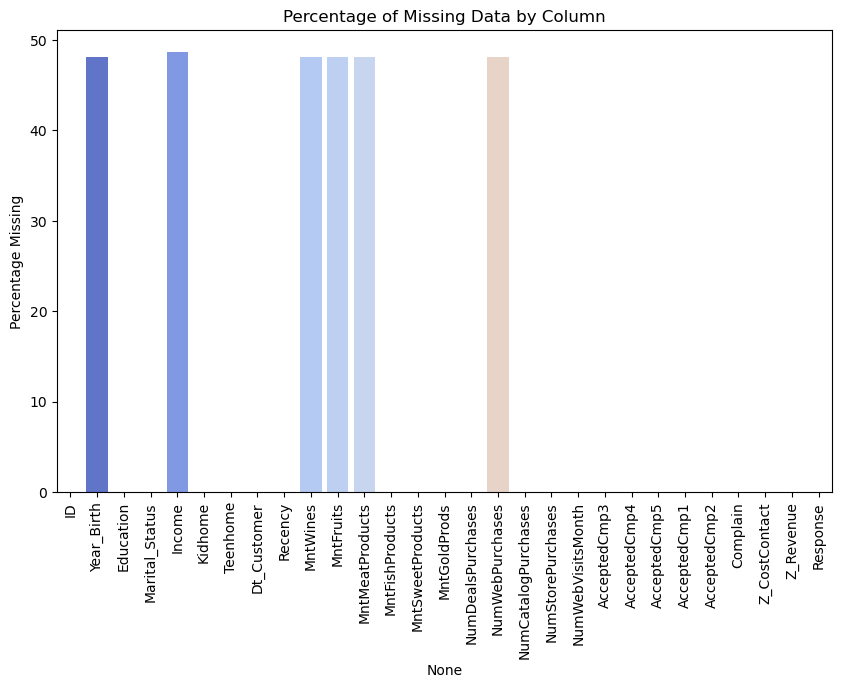

In [5]:
# Plotting the missing data percentage per column
import seaborn as sns
import matplotlib.pyplot as plt

# Create a bar plot for missing data
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.index, y=missing_data['Percentage'], palette='coolwarm')
plt.title('Percentage of Missing Data by Column')
plt.xticks(rotation=90)
plt.ylabel('Percentage Missing')
plt.show()


* Summary Statistics for Numerical Columns

In [6]:
# Summary statistics for numerical columns
summary_stats = df.describe()
print(summary_stats)


                 ID   Year_Birth         Income      Kidhome     Teenhome  \
count   2240.000000  1162.000000    1150.000000  2240.000000  2240.000000   
mean    5592.159821  1968.864028   51604.226087     0.444196     0.506250   
std     3246.662198    11.531349   21625.580361     0.538398     0.544538   
min        0.000000  1940.000000    2447.000000     0.000000     0.000000   
25%     2828.250000  1960.000000   35182.500000     0.000000     0.000000   
50%     5458.500000  1970.000000   50840.000000     0.000000     0.000000   
75%     8427.750000  1977.000000   67429.750000     1.000000     1.000000   
max    11191.000000  1995.000000  160803.000000     2.000000     2.000000   

           Recency     MntWines    MntFruits  MntMeatProducts  \
count  2240.000000  1162.000000  1162.000000      1162.000000   
mean     49.109375   305.436317    26.387263       169.975904   
std      28.962453   341.467278    38.992609       223.593075   
min       0.000000     0.000000     0.000000  

* Distribution of Key Features

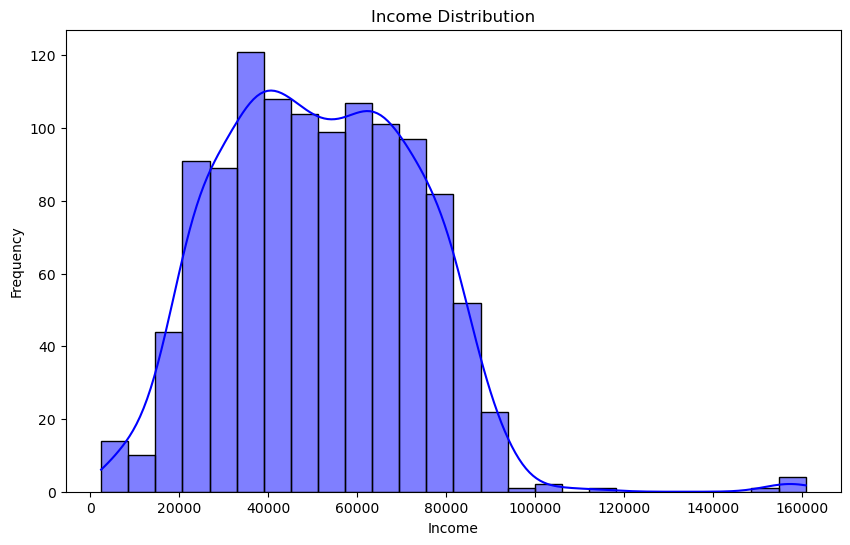

In [7]:
# Plot Income distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'].dropna(), kde=True, color='blue')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()


 The distribution of income is right-skewed, with most customers earning between X and Y. This insight could be used to segment customers for targeted campaigns.

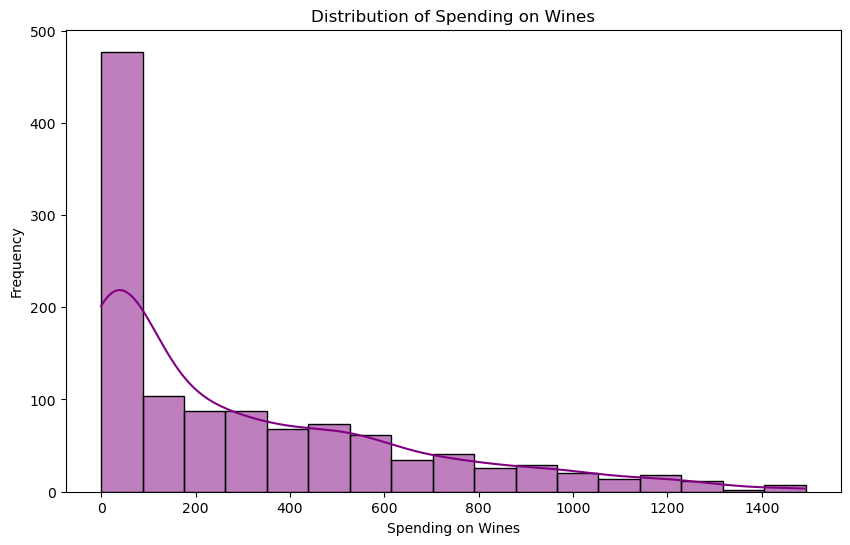

In [8]:
# Plot distribution of spending on wines
plt.figure(figsize=(10, 6))
sns.histplot(df['MntWines'], kde=True, color='purple')
plt.title('Distribution of Spending on Wines')
plt.xlabel('Spending on Wines')
plt.ylabel('Frequency')
plt.show()


* Boxplots for Outlier Detection

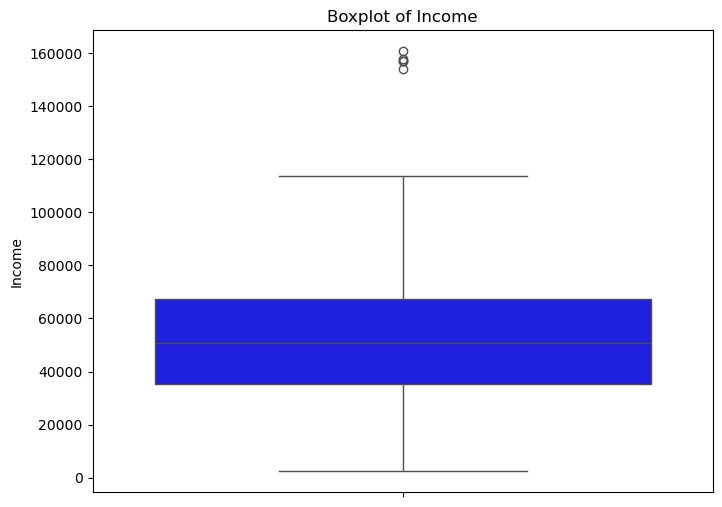

In [9]:
# Boxplot for Income
plt.figure(figsize=(8, 6))
sns.boxplot(y='Income', data=df, color='blue')
plt.title('Boxplot of Income')
plt.show()


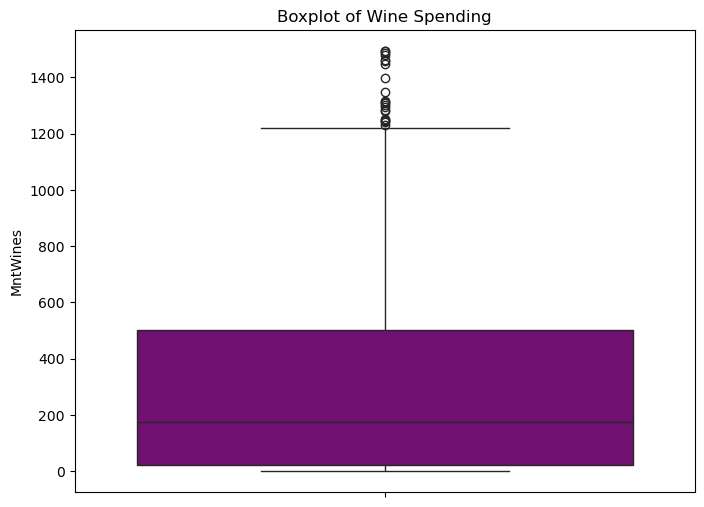

In [10]:
# Boxplot for Wine Spending
plt.figure(figsize=(8, 6))
sns.boxplot(y='MntWines', data=df, color='purple')
plt.title('Boxplot of Wine Spending')
plt.show()

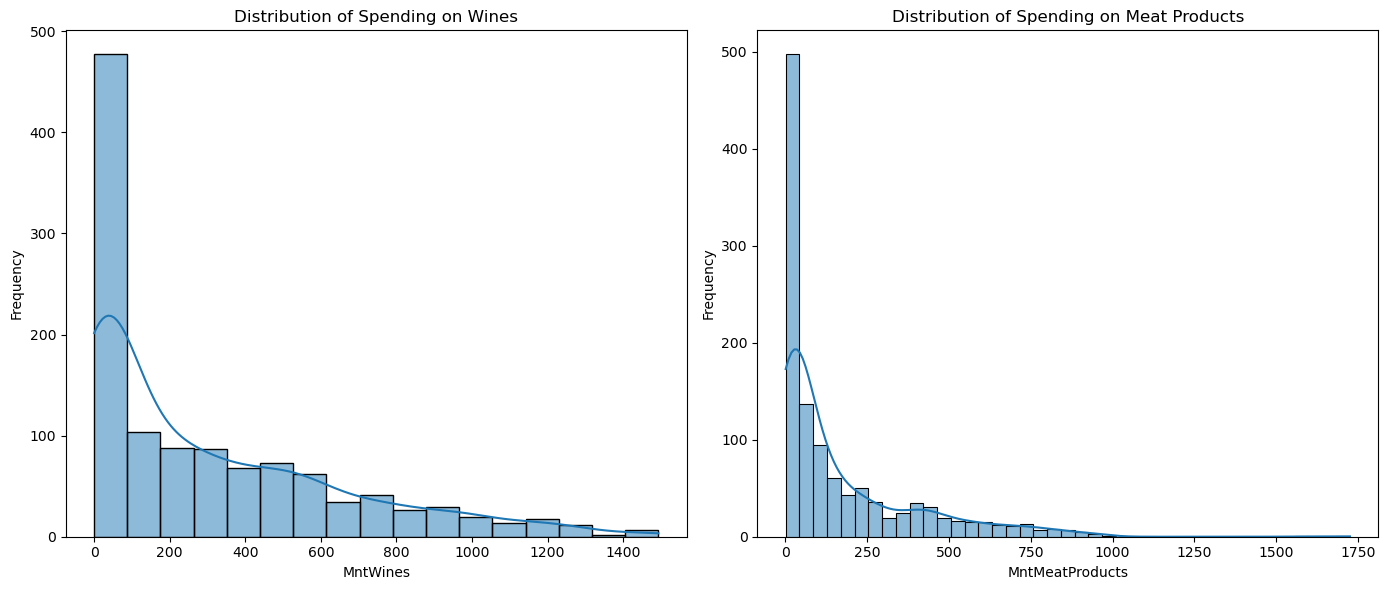

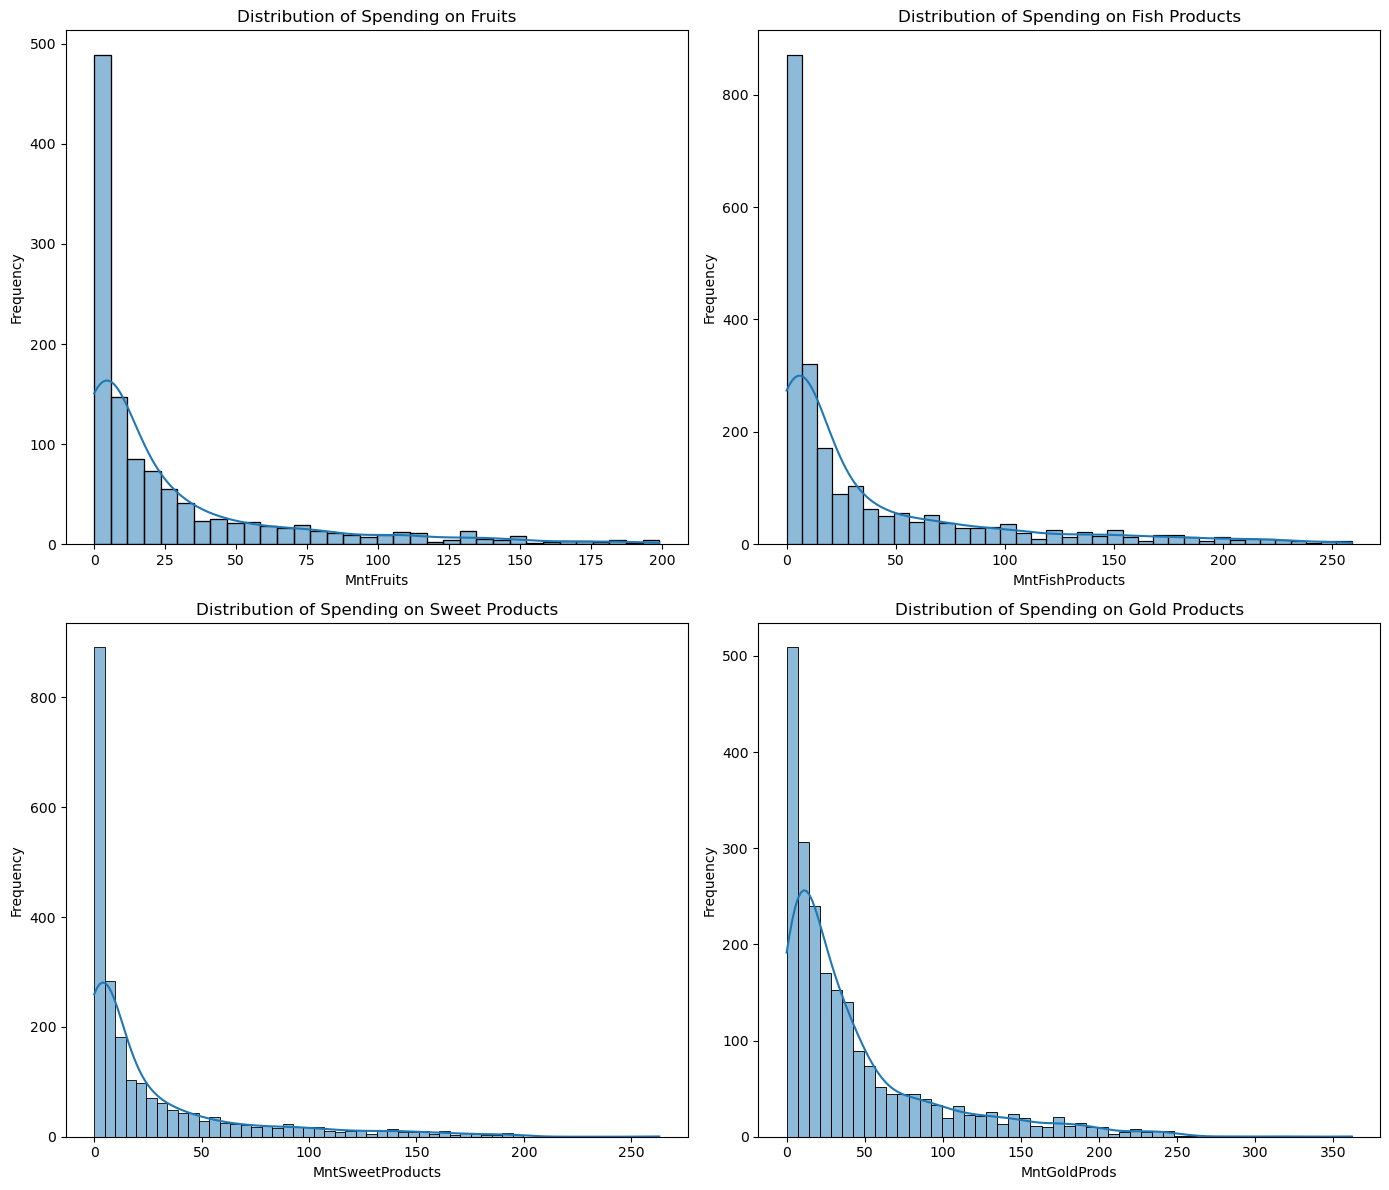

In [11]:
# Spending Group
import matplotlib.pyplot as plt
import seaborn as sns

# Group 1: Higher spending categories (Wines and Meat Products)
group1 = ['MntWines', 'MntMeatProducts']
titles_group1 = ['Wines', 'Meat Products']

# Group 2: Lower spending categories (Fruits, Fish, Sweet, and Gold Products)
group2 = ['MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
titles_group2 = ['Fruits', 'Fish Products', 'Sweet Products', 'Gold Products']

# Plot Group 1
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(group1):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of Spending on {titles_group1[i]}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot Group 2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
for i, col in enumerate(group2):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of Spending on {titles_group2[i]}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()




Relationship Between Features

* Correlation Analysis

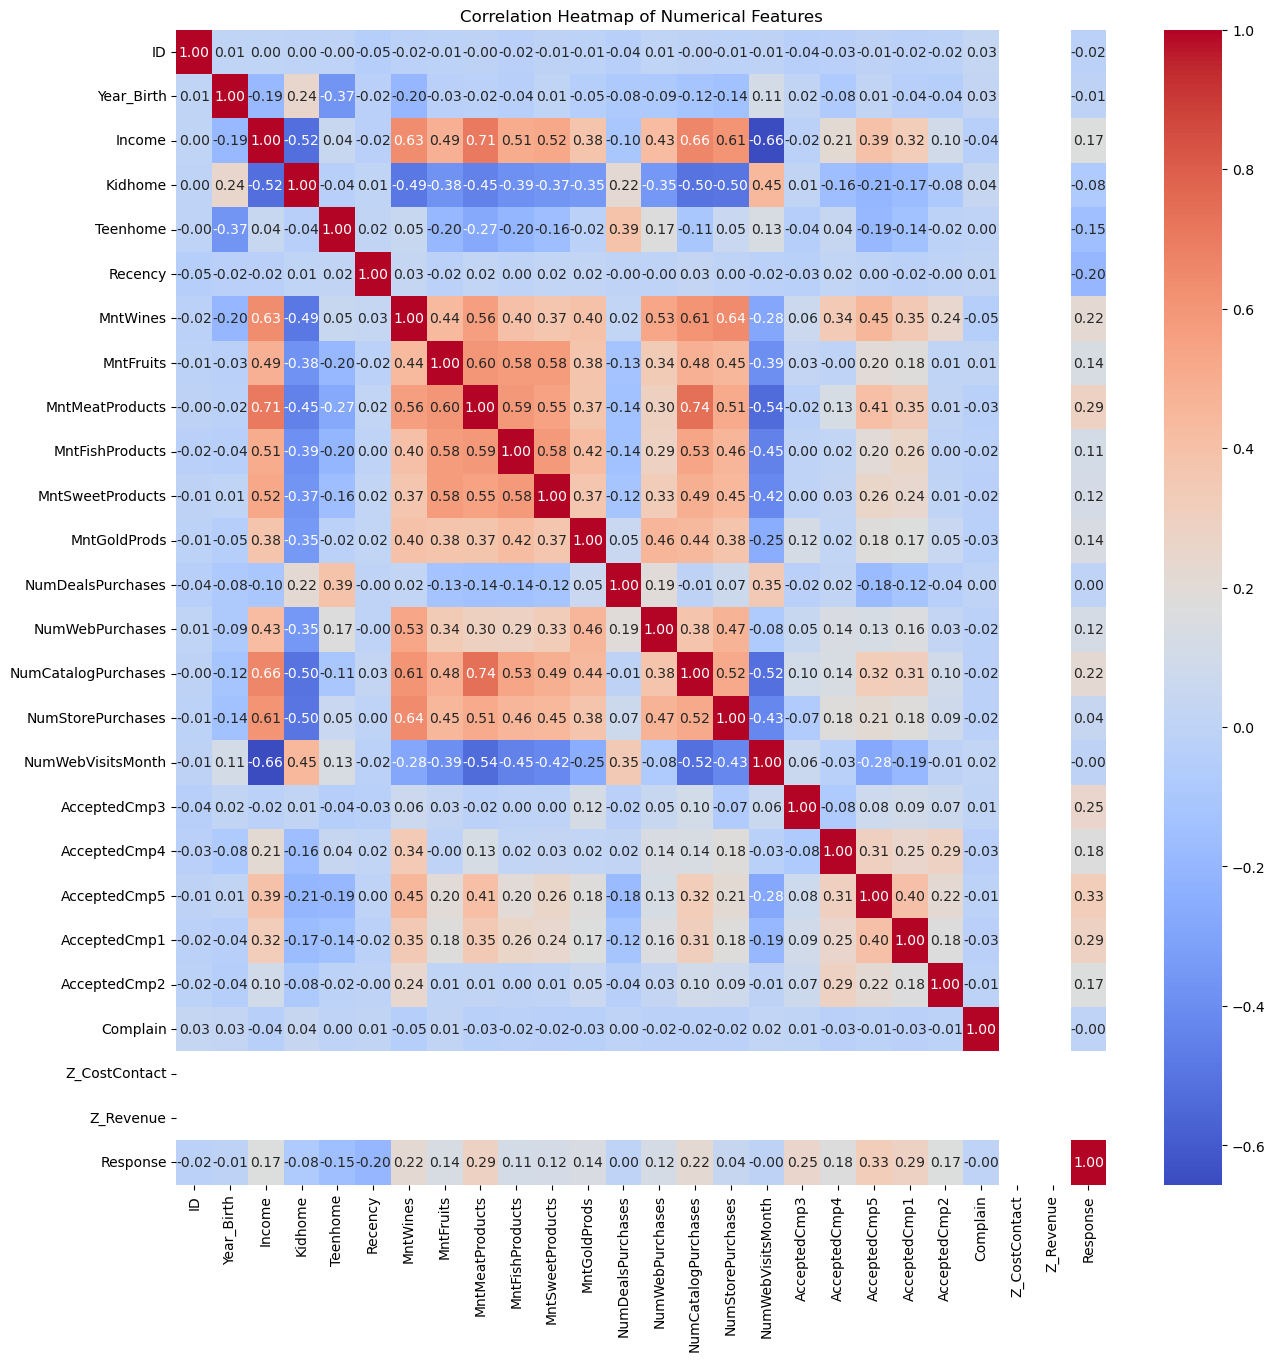

In [12]:
# Correlation heatmap

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])

# Plot the correlation heatmap for numerical columns only
plt.figure(figsize=(15, 15))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


* Bar Plots to Compare Categorical Variables

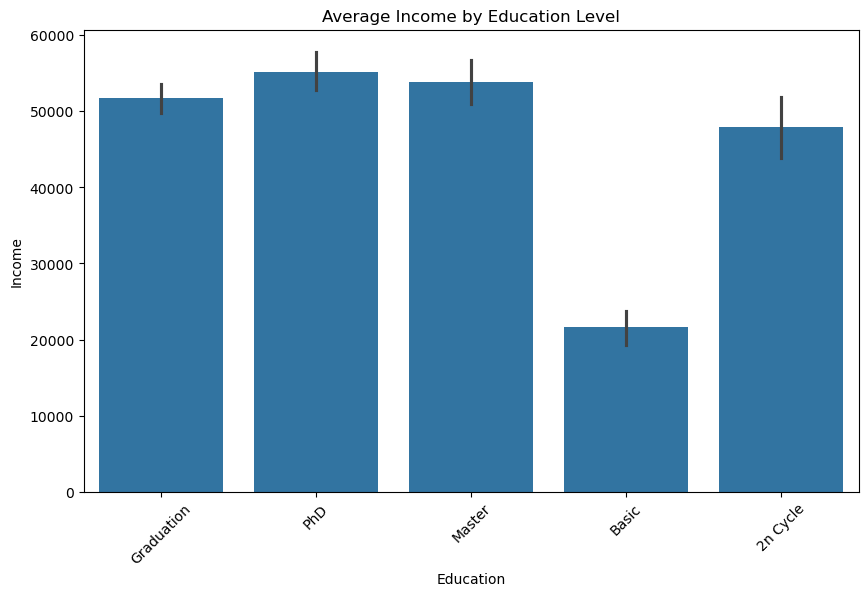

In [13]:
# Bar plot for average income per education level
plt.figure(figsize=(10, 6))
sns.barplot(x='Education', y='Income', data=df)
plt.title('Average Income by Education Level')
plt.ylabel('Income')
plt.xlabel('Education')
plt.xticks(rotation=45)
plt.show()


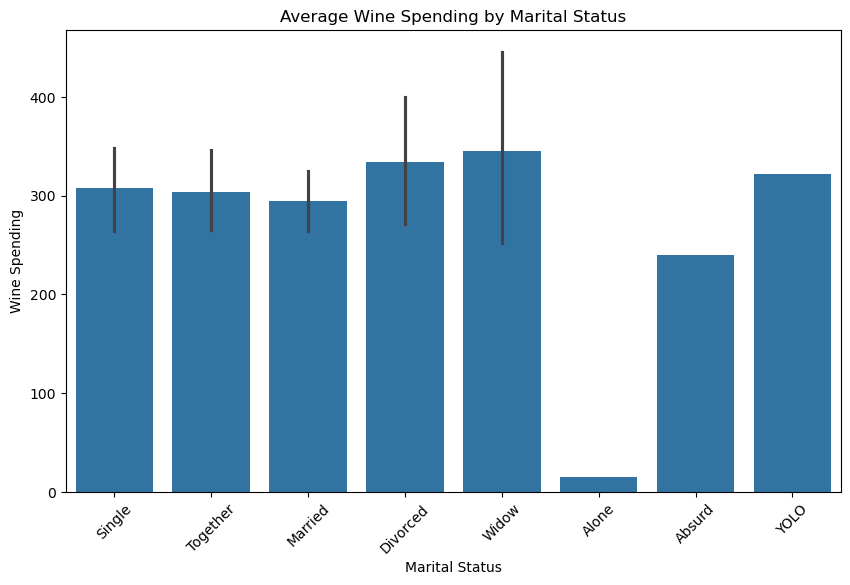

In [14]:
# Bar plot for average wine spending by marital status
plt.figure(figsize=(10, 6))
sns.barplot(x='Marital_Status', y='MntWines', data=df)
plt.title('Average Wine Spending by Marital Status')
plt.ylabel('Wine Spending')
plt.xlabel('Marital Status')
plt.xticks(rotation=45)
plt.show()

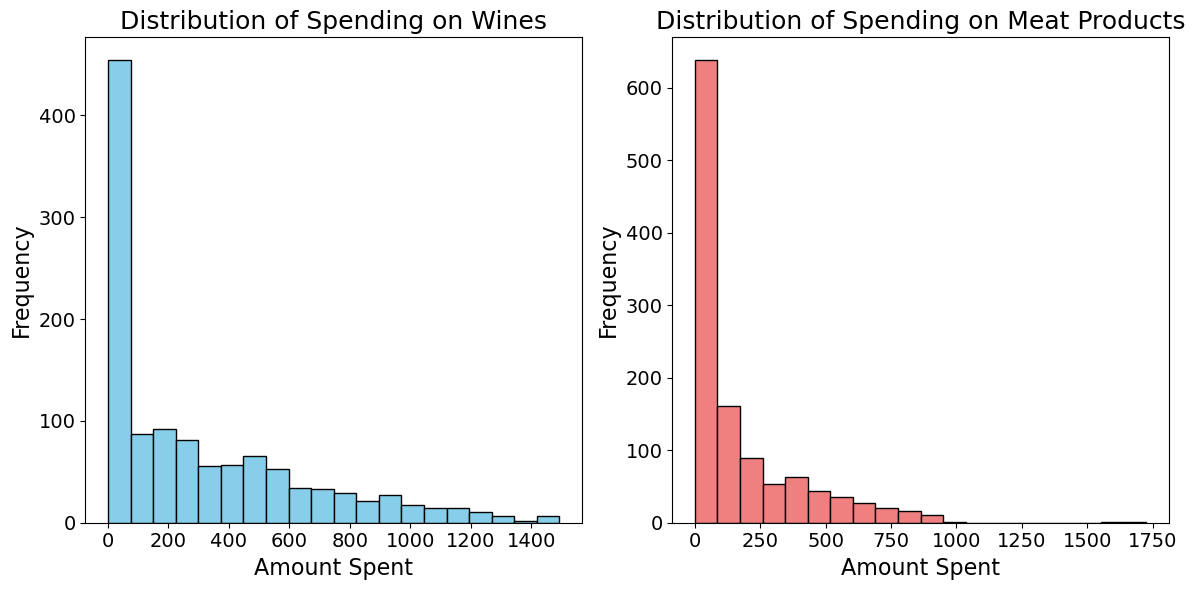

In [27]:
# Plot spending distribution for Wines and Meat Products with larger fonts
plt.figure(figsize=(12, 6))

# Distribution of Spending on Wines
plt.subplot(1, 2, 1)
plt.hist(df['MntWines'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Spending on Wines', fontsize=18)
plt.xlabel('Amount Spent', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Distribution of Spending on Meat Products
plt.subplot(1, 2, 2)
plt.hist(df['MntMeatProducts'], bins=20, color='lightcoral', edgecolor='black')
plt.title('Distribution of Spending on Meat Products', fontsize=18)
plt.xlabel('Amount Spent', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()


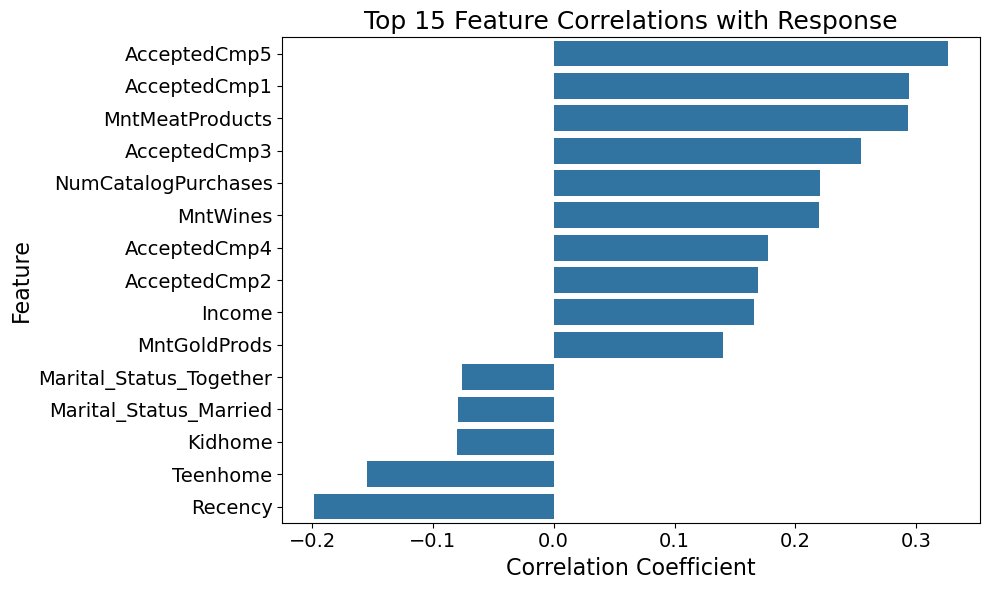

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert categorical variables to dummy/indicator variables
data_encoded = pd.get_dummies(df, drop_first=True)

# Compute the correlation matrix with the response variable
correlation_matrix = data_encoded.corr()

# Select the correlation values related to the 'Response' variable
response_correlation = correlation_matrix['Response'].drop('Response').sort_values(ascending=False)

# Select the top 15 positively and negatively correlated features
top_positive_corr = response_correlation[response_correlation > 0].head(10)
top_negative_corr = response_correlation[response_correlation < 0].tail(5)

# Combine the top positive and negative correlations
top_corr = pd.concat([top_positive_corr, top_negative_corr])

# Plot the top correlated features
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Top 15 Feature Correlations with Response', fontsize=18)
plt.xlabel('Correlation Coefficient', fontsize=16)
plt.ylabel('Feature', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


## Splitting and Preprocessing Slides 

### Split the Dataset

In [4]:
from sklearn.model_selection import train_test_split

# Defining features (X) and target (y)
X = df.drop('Response', axis=1)
y = df['Response']

# Split the dataset into 80% training, 10% validation, and 10% testing
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Output size of the splits
print(f"Training Data Points: {X_train.shape[0]}")
print(f"Validation Data Points: {X_val.shape[0]}")
print(f"Testing Data Points: {X_test.shape[0]}")

Training Data Points: 1792
Validation Data Points: 224
Testing Data Points: 224


### Preprocessing (Scaling and Encoding)

In [3]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Check the columns before any preprocessing
print("Columns before preprocessing (raw dataset):")
print(df.columns)  # This should reflect the initial 29 features, including categorical features

# Count the number of features before preprocessing
initial_features = df.drop('Response', axis=1).shape[1]
initial_data_points = df.shape[0]
print(f"Initial feature count (excluding target): {initial_features}")
print(f"Initial data points: {initial_data_points}")

# Step 2: One-Hot Encoding for Categorical Columns (Marital_Status, Education)
df = pd.get_dummies(df, columns=['Marital_Status', 'Education'], drop_first=True)

# Step 3: Scaling Numerical Columns using StandardScaler
scaler = StandardScaler()
numerical_columns = ['Income', 'MntWines', 'MntMeatProducts', 'MntFishProducts']
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Step 4: Count the number of features after preprocessing
processed_features = df.drop('Response', axis=1).shape[1]
print(f"Processed feature count: {processed_features}")


Columns before preprocessing (raw dataset):
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')
Initial feature count (excluding target): 28
Initial data points: 2240
Processed feature count: 37
